# Visualization of Multiple Polygons

## Introduction

So I started to work my way through the Udemy course [__Udemy 30-Day Map Challenge 2025: Director's Cut__](https://www.udemy.com/course/30-day-map-challenge-2025-directors-cut/).  One of the sessions was on visualizations of multiple overlapping Polygons.  To some extent I was left dissatisified by the solution presented in the course, so this is my take on the problem

## The problem

The challenge is to portray the ecological ranges of the threatened mammals in the Australian region (note the subtle distinction: "Australian region""and not "Australia": this covers a hack that I will explain below).  There are over 400 species, and some may have multiple ranges.

It is amusing that both __matplotlib__ and __plotnine__ have the same problem: "How to users modify the appearence of Legends?".  Both packages have different ways to solve this problem: see below for examples.

---------------------

## Implementation

### Load packages and magics

Import required libraries:

- geodatasets will give us the Australian coastline
- geopandas, to goto for georeferenced sata management
- matplotlib, for old school plotting
- numpy for numerical work
- plotnine for new school plotting
- shapely for geometric data management

In [40]:
import os

import geodatasets as gds
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import plotnine as p9
from matplotlib.colors import ListedColormap
from shapely import Polygon
from shapely.geometry import box

__watermark__ provides reproducability information

In [41]:
%load_ext watermark

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark


------------------

### Data loading

We use the IUCN database of threatened species to download a subset of threatened terrestial mammals.  We will later filter this down to Australian region mammals.

In [42]:
file = "MAMMALS_TERRESTRIAL_ONLY.zip"


gdf = gpd.read_file(file)
print(gdf.crs)
print(len(gdf))
gdf.head(3)

EPSG:4326
12703


,id_no,sci_name,presence,origin,seasonal,compiler,yrcompiled,citation,subspecies,subpop,...,order_,family,genus,category,marine,terrestria,freshwater,SHAPE_Leng,SHAPE_Area,geometry
0,18,Abrocoma boliviensis,1,1,1,IUCN SSC Small Mammal Specialist Group,2016,IUCN SSC Small Mammal Specialist Group,NaN,NaN,...,RODENTIA,ABROCOMIDAE,Abrocoma,CR,false,true,false,0.305150,0.005520,"POLYGON ((-64.46864 -17.88625, -64.45733 -17.8..."
1,137,Acerodon celebensis,1,1,1,IUCN,2022,IUCN (International Union for Conservation of ...,NaN,NaN,...,CHIROPTERA,PTEROPODIDAE,Acerodon,VU,false,true,false,0.497459,0.009368,"POLYGON ((125.426 2.74894, 125.4247 2.74344, 1..."
2,137,Acerodon celebensis,1,1,1,IUCN,2022,IUCN (International Union for Conservation of ...,NaN,NaN,...,CHIROPTERA,PTEROPODIDAE,Acerodon,VU,false,true,false,1.224802,0.046804,"POLYGON ((125.9087 -1.97096, 125.9154 -1.97336..."


Now create a box that will hold the Australian continent  (Australia as a country extends to Cocos Islands, a long way west, which would make the maps look strange).  The EPSG:4326 tells Geopandas that we have a Coordinate Reference System, where latitude is Y and longitude is X.

We plot the box, just to make sure we have the X and Y coordinates correctly assigned

110 -45 160 -10


<Axes: >

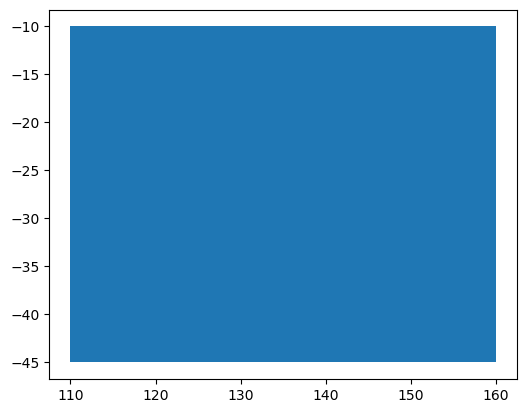

In [43]:
oz_bbox = (110, -45, 160, -10)
minx, miny, maxx, maxy = oz_bbox
print(minx, miny, maxx, maxy)
bbox_gdf = gpd.GeoDataFrame(geometry=[box(minx, miny, maxx, maxy)], crs="EPSG:4326")
bbox_gdf.plot()

### Data processing

We now clip the global polygons to just those the intersect or are inside our box.  We have 1014 polygons to visualize

In [44]:
gdf_oz = gpd.clip(gdf, bbox_gdf)
len(gdf_oz)

1014

We now list the unique Orders in our (filtered) database.  Orders seems a natural way to group the polygons, if only because this is the smallest number of possible groupings (versus Genus, Family, or Species)

In [45]:
gdf_oz["order_"].unique()

<ArrowStringArray>
[        'RODENTIA',       'LAGOMORPHA',        'CARNIVORA',
    'DIPROTODONTIA',      'MONOTREMATA',   'DASYUROMORPHIA',
       'CHIROPTERA',  'PERAMELEMORPHIA', 'NOTORYCTEMORPHIA',
     'EULIPOTYPHLA',     'ARTIODACTYLA',         'PRIMATES']
Length: 12, dtype: str

In [46]:
print(f"""
Order count   =  {len(gdf_oz["order_"].unique()):4}, 
Genus count   =  {len(gdf_oz["genus"].unique()):4},  
Family count  =  {len(gdf_oz["family"].unique()):4}, 
Species count =  {len(gdf_oz["sci_name"].unique()):4}""")


Order count   =    12, 
Genus count   =   136,  
Family count  =    34, 
Species count =   422


-----------------------

## Initial visualization

The inital attempt to visualize this dataset was to plot all polygons, color-coded by the Order of each species.  We make each polygon very transparent, so that we can perceive the overall density of threatened species.

Note that when we color-code with very transparent fill color, the corresponding legend is very hard to understand. We get the Legend handles (in this case, references top 2DLine objects), and set the transparency to fully opaque.

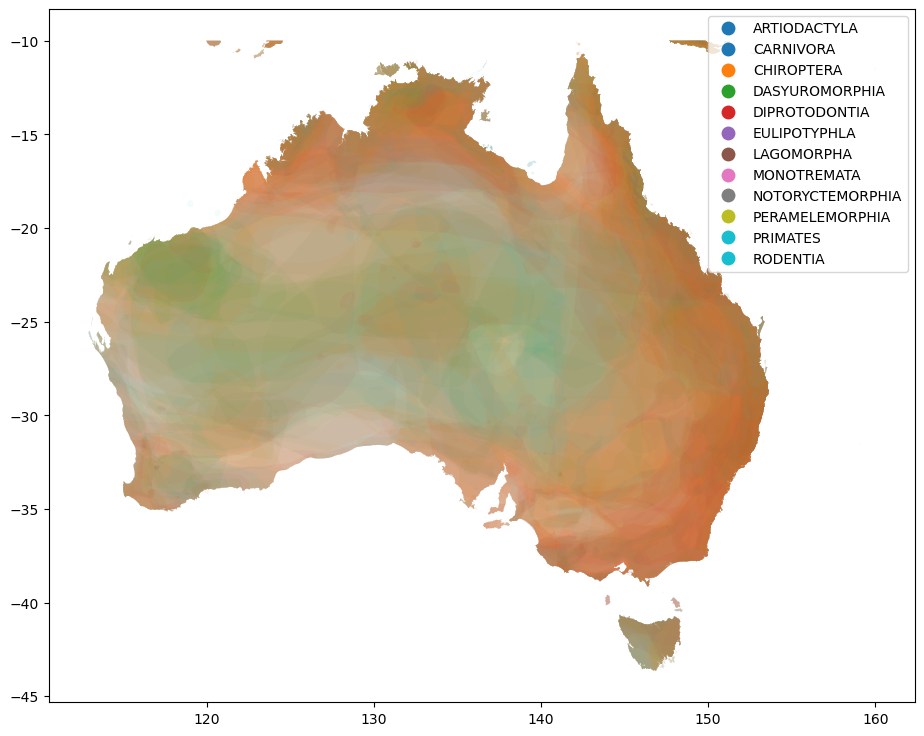

In [47]:
f, ax = plt.subplots(1, 1, figsize=(14, 9))

gdf_oz.plot(column="order_", alpha=0.05, linewidth=0.5, ax=ax, legend=True)

# set legend colors to be opaque
for h in ax.get_legend().legend_handles:
    h.set(alpha=1)
# end for

### Other approaches

I was deeply dissatisified with the map above.  12 Orders is probably too many  color-codes to easily understand - by definition, Orders are (sort of) unrelated, but adjacent colors seems to imply meaningful proximity.  For example "DASYUROMORPHIA" and "NOTORYCTEMORPHIA" are both sort-of green, so a green shaded area of the map doen't really tell us much about which Order is represented where on the map

#### Borders

The next approach is to just plot the borders of the regions containing threatened mammals in the same color.  This graphic brings out the ecology-sensitive boundaries:
the Great Dividing Range, the Murray Darling river system.

Note that because of our box-style clipping, we get bits of East Timor and PNG as well (not a bad thing to be reminded of our proximity to our northern neighbours, but unintended)

<Axes: >

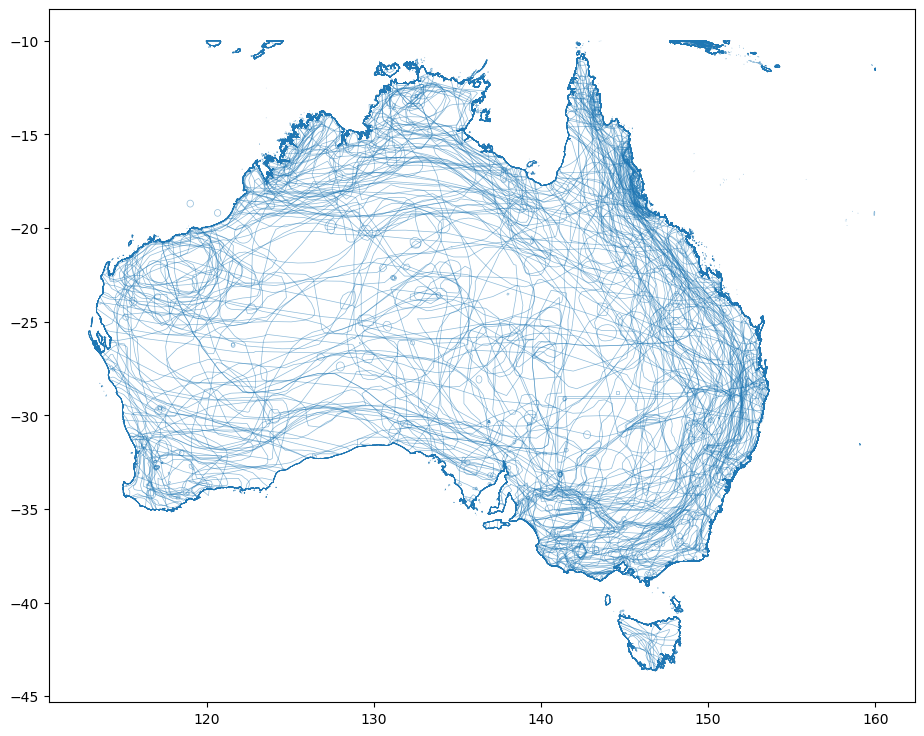

In [48]:
f, ax = plt.subplots(1, 1, figsize=(14, 9))

gdf_oz.boundary.plot(
    alpha=0.5,
    linewidth=0.5,
    ax=ax,
)

#### Borders with colors

We now replace the Polygons in our filtered dataset with LineStrings.  This lets us plot the borders colored by Order.

Again, for legibility we set the Legend to have fully opaque color patches

In [49]:
gdf_oz2 = gdf_oz.copy()
gdf_oz2["geometry"] = gdf_oz2.boundary

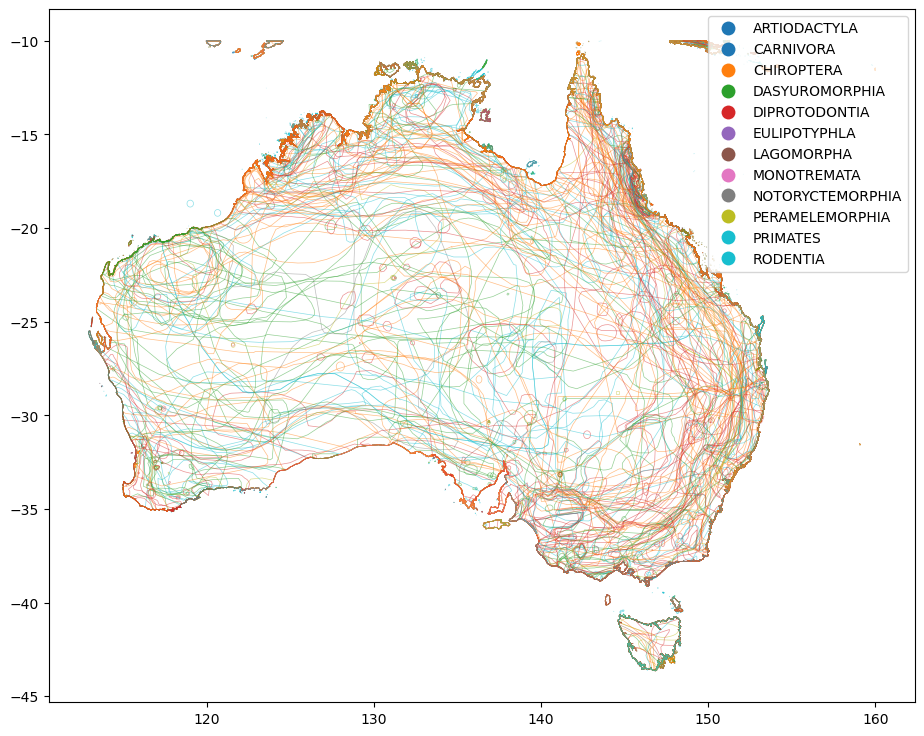

In [50]:
f, ax = plt.subplots(1, 1, figsize=(14, 9))

gdf_oz2.plot(
    column="order_",
    alpha=0.5,
    linewidth=0.5,
    ax=ax,
    legend=True,
)

for h in ax.get_legend().legend_handles:
    h.set(alpha=1)
# end for

---------------------------

### The real question

None of the maps above help answer the question: "where in Australia are the most threatened mammal species?"

To answer this, I build a 1 degree grid that covers Australia (not using a equal-area projection is a bit of a hack, but in this case I feel this would be false precision)

In [51]:
minx, miny, maxx, maxy = oz_bbox

In [52]:
polys = []
for lon in range(minx, maxx + 1):
    for lat in range(miny, maxy + 1):
        coords = (
            (lon, lat),
            (lon + 1, lat),
            (lon + 1, lat + 1),
            (lon, lat + 1),
            (lon, lat),
        )
        poly = Polygon(coords)
        polys.append(poly)
    # end for
# end for

grid = gpd.GeoDataFrame({"geometry": polys})

Plot the grid to be sure we have X and Y correctly

<Axes: >

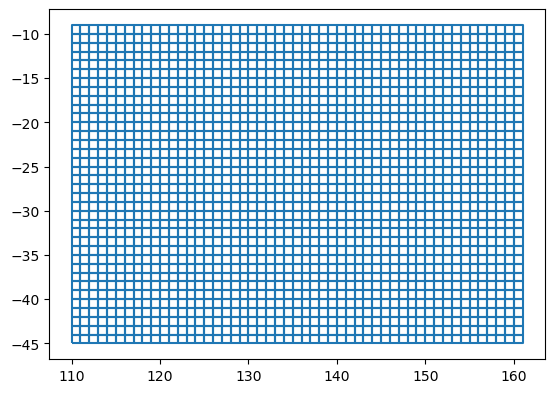

In [53]:
grid.boundary.plot()

Get the centre points of each grid square

In [54]:
grid_ctr = grid.centroid

For each grid square, we get the count of threatened species ranges that includes the grid square centre point

In [55]:
counts = []
for point in grid_ctr:

    count = sum(gdf_oz.contains(point))
    counts.append(count)
# end for

Get the maximum count of threatened species in a 1 degree square (worryingly high)

In [56]:
max(counts)

71

Add the counts as an attribute of the grid-square GeoDataFrame

In [57]:
grid["count"] = counts

We now plot the grid-squares, color coded by species count.  We choose a reversed Red-Yellow-Blue (-> Blue=low, Yellow=medium, Red=high) color map. The oceans will have zero terrestial species, so we should code 0 as blue for water, or cool for low danger.  We want Red (for danger) to be associated with the grid squares with the most threatened species.

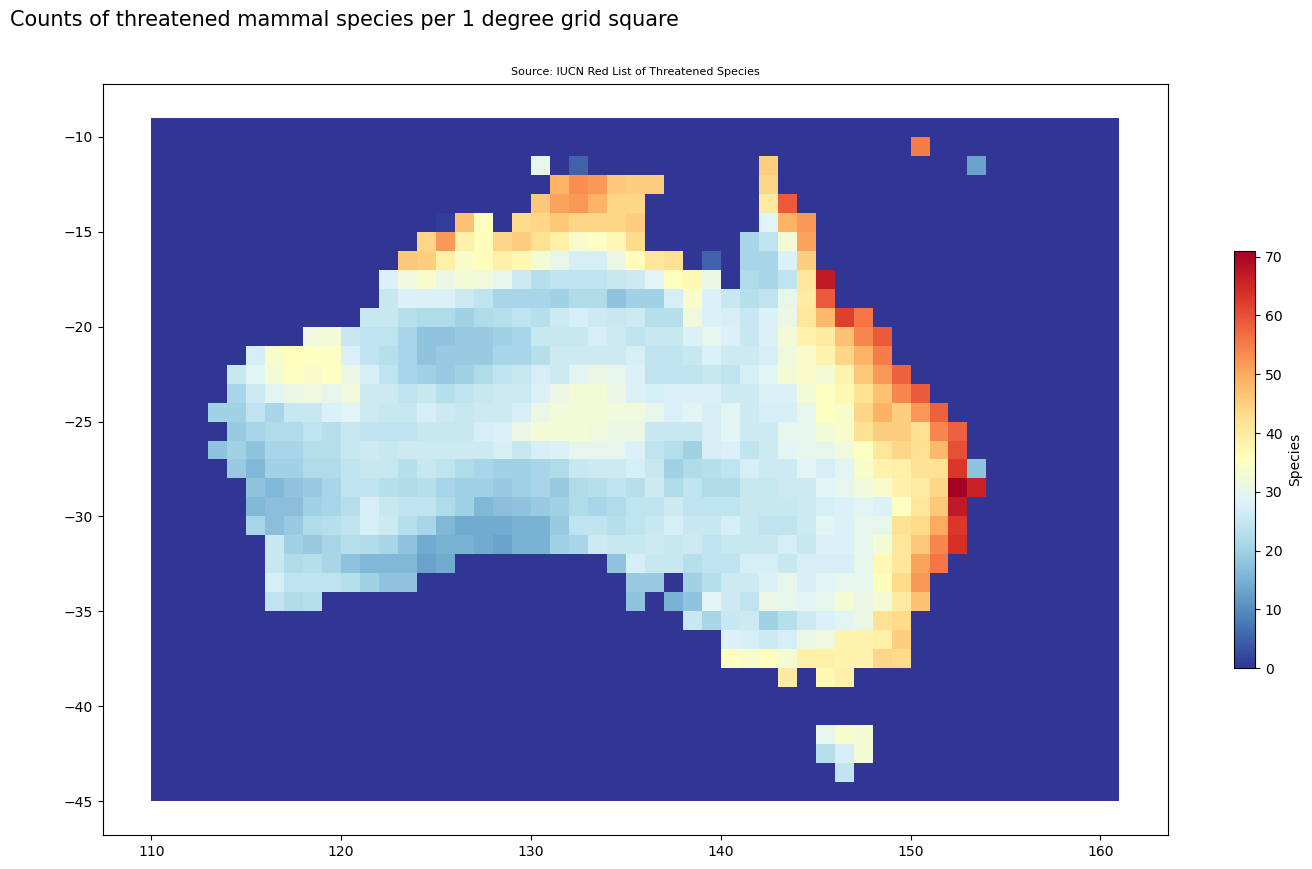

In [58]:
f, ax = plt.subplots(1, 1, figsize=(14, 9))

grid.plot(
    column="count",
    cmap="RdYlBu_r",
    ax=ax,
    legend=True,
    legend_kwds={"shrink": 0.5, "label": "Species"},
)
ax.set_title(
    "Source: IUCN Red List of Threatened Species",
    fontsize=8,
)
f.suptitle(
    "Counts of threatened mammal species per 1 degree grid square",
    ha="right",
    fontsize=15,
    x=0.45,
)
plt.tight_layout()

#### Discussion

I must admit I was initially surprised by the map: but then again, Australia is a country of coast huggers, and development is probably the biggest threat to mammal species.

--------------------------------------

### Plot multiples

We get the Australian coastline, provided by the ABS, and included in the GeoDataSets package.  We will be drawing little maps, so don't need a very detailed coastline - hence the __simplify__ call.  We plot the result to check, all OK

<Axes: >

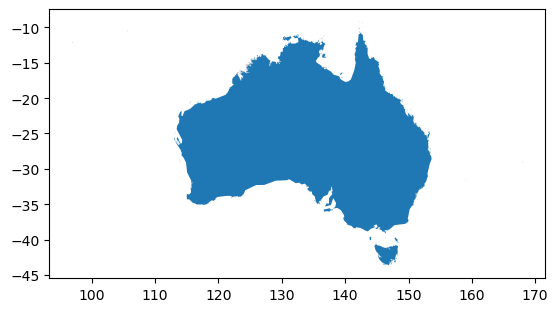

In [59]:
oz_coast = gpd.read_file(gds.get_path("abs australia"))

tolerance = 0.1
oz_coast["geometry"] = oz_coast["geometry"].simplify(tolerance)

oz_coast.plot()

#### Map annotations

Not really map annotations, but I decided that every where we show an Order name, we should also show the common name.  We build a dictionary to hold the Order nae -> Common Name mapping.

In [60]:
sorted(gdf_oz["order_"].unique())

['ARTIODACTYLA',
 'CARNIVORA',
 'CHIROPTERA',
 'DASYUROMORPHIA',
 'DIPROTODONTIA',
 'EULIPOTYPHLA',
 'LAGOMORPHA',
 'MONOTREMATA',
 'NOTORYCTEMORPHIA',
 'PERAMELEMORPHIA',
 'PRIMATES',
 'RODENTIA']

In [61]:
common_names = {
    "ARTIODACTYLA": "Even-toed ungulates",
    "CARNIVORA": "Carnivorans",
    "CHIROPTERA": "Bats",
    "DASYUROMORPHIA": "Carnivorous marsupials",
    "DIPROTODONTIA": "Diprotodont marsupials",
    "EULIPOTYPHLA": "Insectivores",
    "LAGOMORPHA": "Lagomorphs",
    "MONOTREMATA": "Monotremes or egg-laying mammals",
    "NOTORYCTEMORPHIA": "Marsupial moles",
    "PERAMELEMORPHIA": "Bandicoots and bilbies",
    "PRIMATES": "Primates",
    "RODENTIA": "Rodents",
}

#### Plotting density on multiple same scale maps
Conveniently we have 12 Orders, which gives us 3 rows, each of 4 mini-maps.

For each order, we plot the Polygon of species range in a faint red, then plot the coastline, set the title, and set the limits of the map to our bounding box

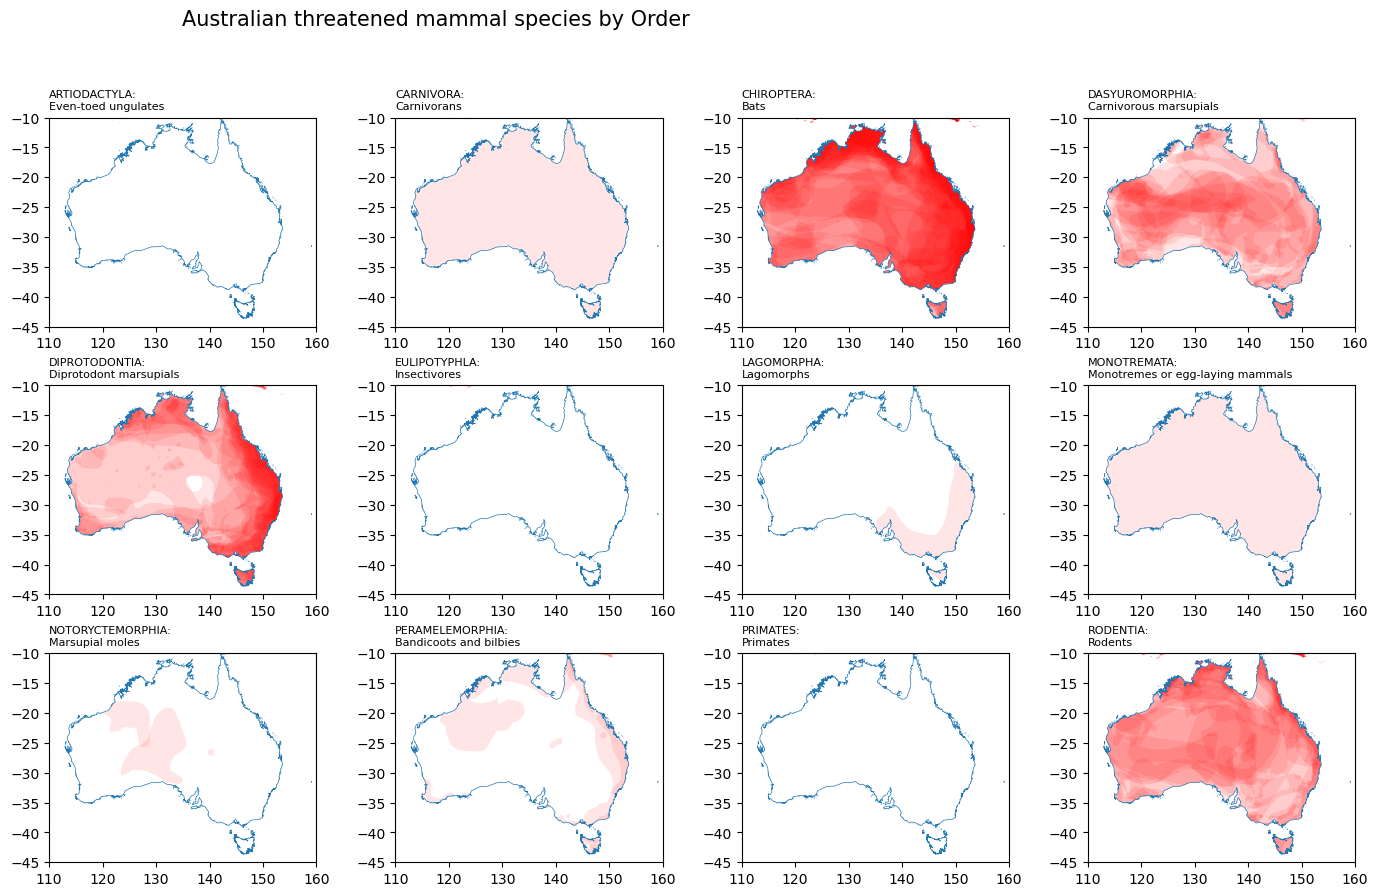

In [62]:
f, axes = plt.subplots(nrows=3, ncols=4, figsize=(14, 9))

# flatten the Axes array to make iteration easier
# each Order gets its own Axes object
for o, a in zip(sorted(gdf_oz["order_"].unique()), axes.flatten()):
    # plot species ranges
    gdf_oz[gdf_oz["order_"] == o].plot(
        ax=a,
        legend=True,
        color="red",
        alpha=0.1,
    )
    # plot the coastline
    oz_coast.boundary.plot(
        linewidth=0.5,
        ax=a,
    )
    # set the title of the mini-map, with common name
    a.set_title(
        "\n" + o + ":\n" + common_names[o],
        fontsize=8,
        ha="left",
        loc="left",
    )
    # set the limit to our bounding box for each mini-map
    a.set_xlim(left=minx, right=maxx)
    a.set_ylim(bottom=miny, top=maxy)
# end for
# set overall title
f.suptitle(
    "Australian threatened mammal species by Order\n\n",
    ha="right",
    fontsize=15,
)
f.tight_layout()

I like this style of graphic a lot more.  The intensity of the red notes the number of species threatened at any given point.  Note that few Orders don't seem to show up:  this is because they are in PNG or East Timor, and only a small sliver of range pokes down below 10 degrees South

------------------

### Plotting density on multiple different scale maps

As a slight variant of the above, here we omit drawing the coastline, and adjust the scale so the combined species regions for an Order fill the map.  We see better that EULIPOTYPHLA and PRIMATES are not really Australian (hence my careful title above : Australian Region)

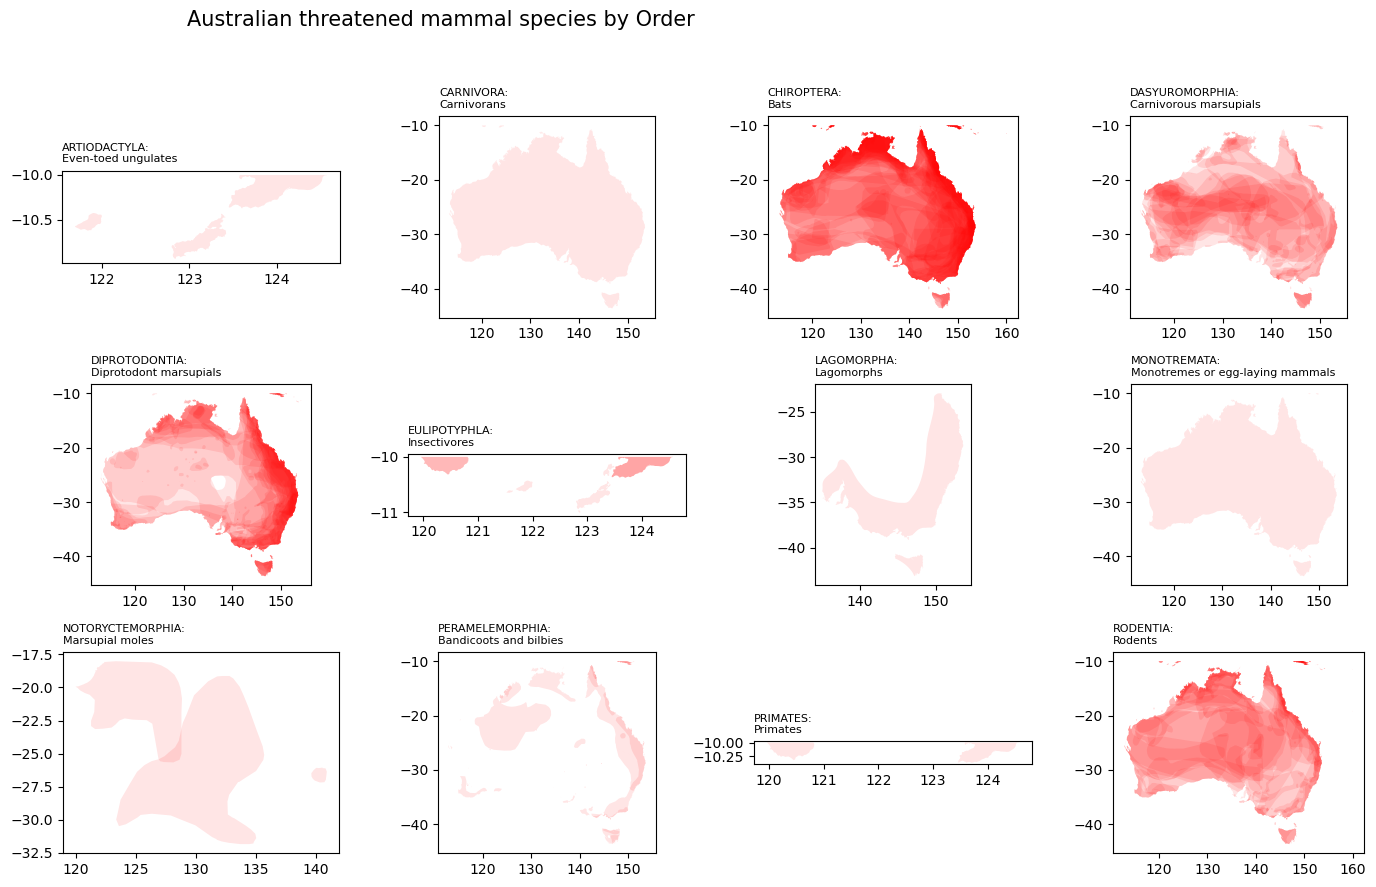

In [63]:
f, axes = plt.subplots(nrows=3, ncols=4, figsize=(14, 9))

# flatten the Axes array so we can iterate over them.  Each Order gets its own Axes object
for o, a in zip(sorted(gdf_oz["order_"].unique()), axes.flatten()):
    # plot the species ranges
    gdf_oz[gdf_oz["order_"] == o].plot(
        ax=a,
        legend=True,
        color="red",
        alpha=0.1,
    )
    # set the title to include Common Name
    a.set_title(
        o + ":\n" + common_names[o],
        fontsize=8,
        ha="left",
        loc="left",
    )

# end for

# set over all title
f.suptitle(
    "Australian threatened mammal species by Order\n\n",
    ha="right",
    fontsize=15,
)
f.tight_layout()

-------------------------------

### New school plotting

In this section, we use the power of __plotnine__ to produce the most elegent maps

#### Single map

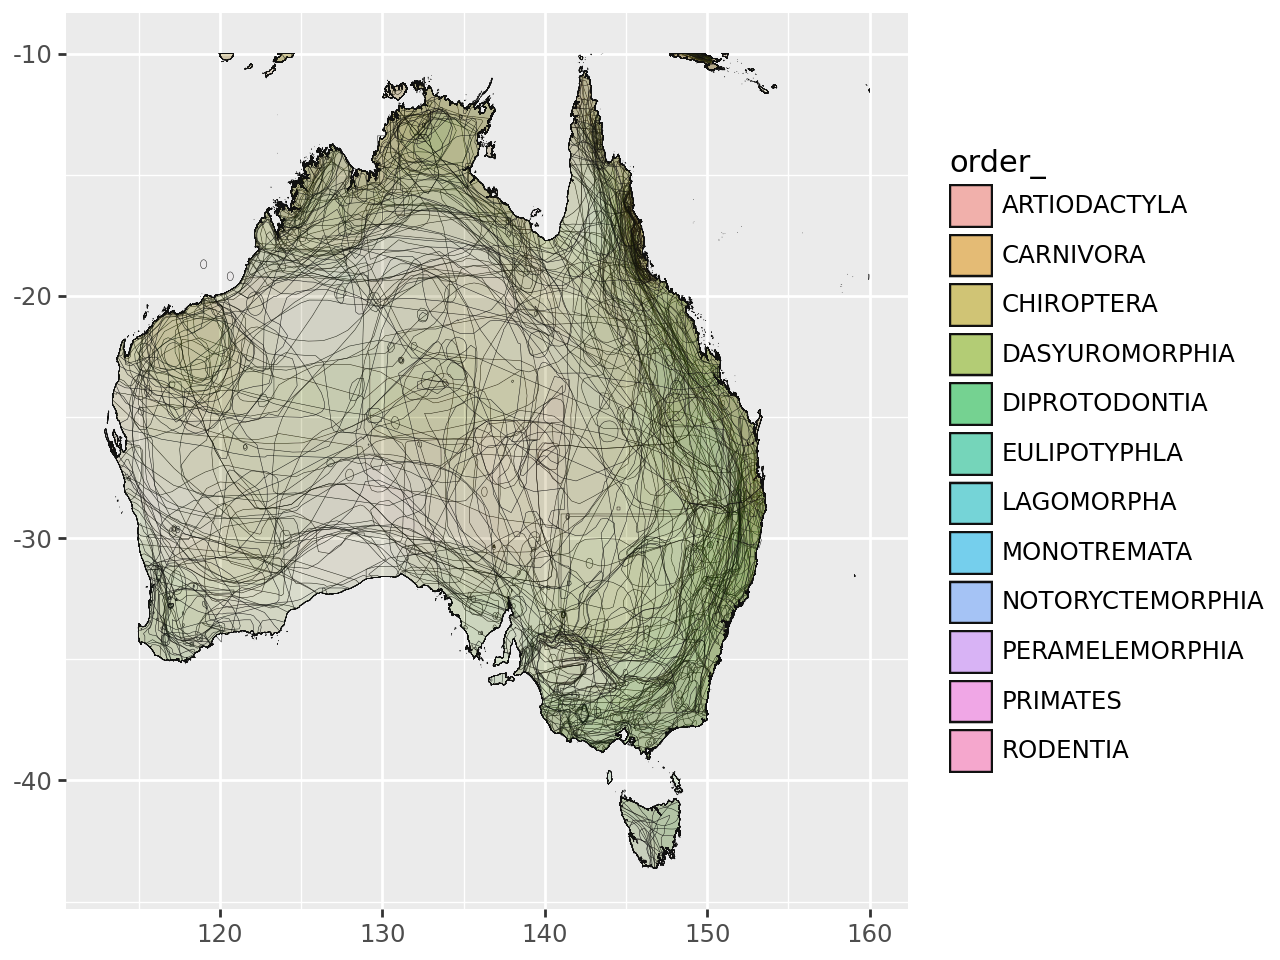

In [64]:
plot = (
    # set data source
    p9.ggplot(data=gdf_oz)
    # draw map, filling species ranges of the same order to same color (very transparent)
    # size sets line thickness
    + p9.geom_map(mapping=p9.aes(fill="order_"), alpha=0.01, size=0.1)
    # set the fill legend color patches to be 50% opaque (not 1%)
    + p9.guides(
        fill=p9.guide_legend(
            override_aes={"alpha": 0.5}  # Legend squares are more opaque for clarity
        )
    )
)
plot

#### Multiple mini-maps

Helper function

In [65]:
def order_namer(o):
    """
    order_namer: return Order name concatenated with common name

    Used in calls to plotnine functions

    Parameters:
    o : string

    Returns:
    Order name concatenated with common name

    Design:
    assumes dictionary common_names, mapping Order name to Common Name
    """
    return o + "\n" + common_names[o]


# end order_namer

Producing mini-maps

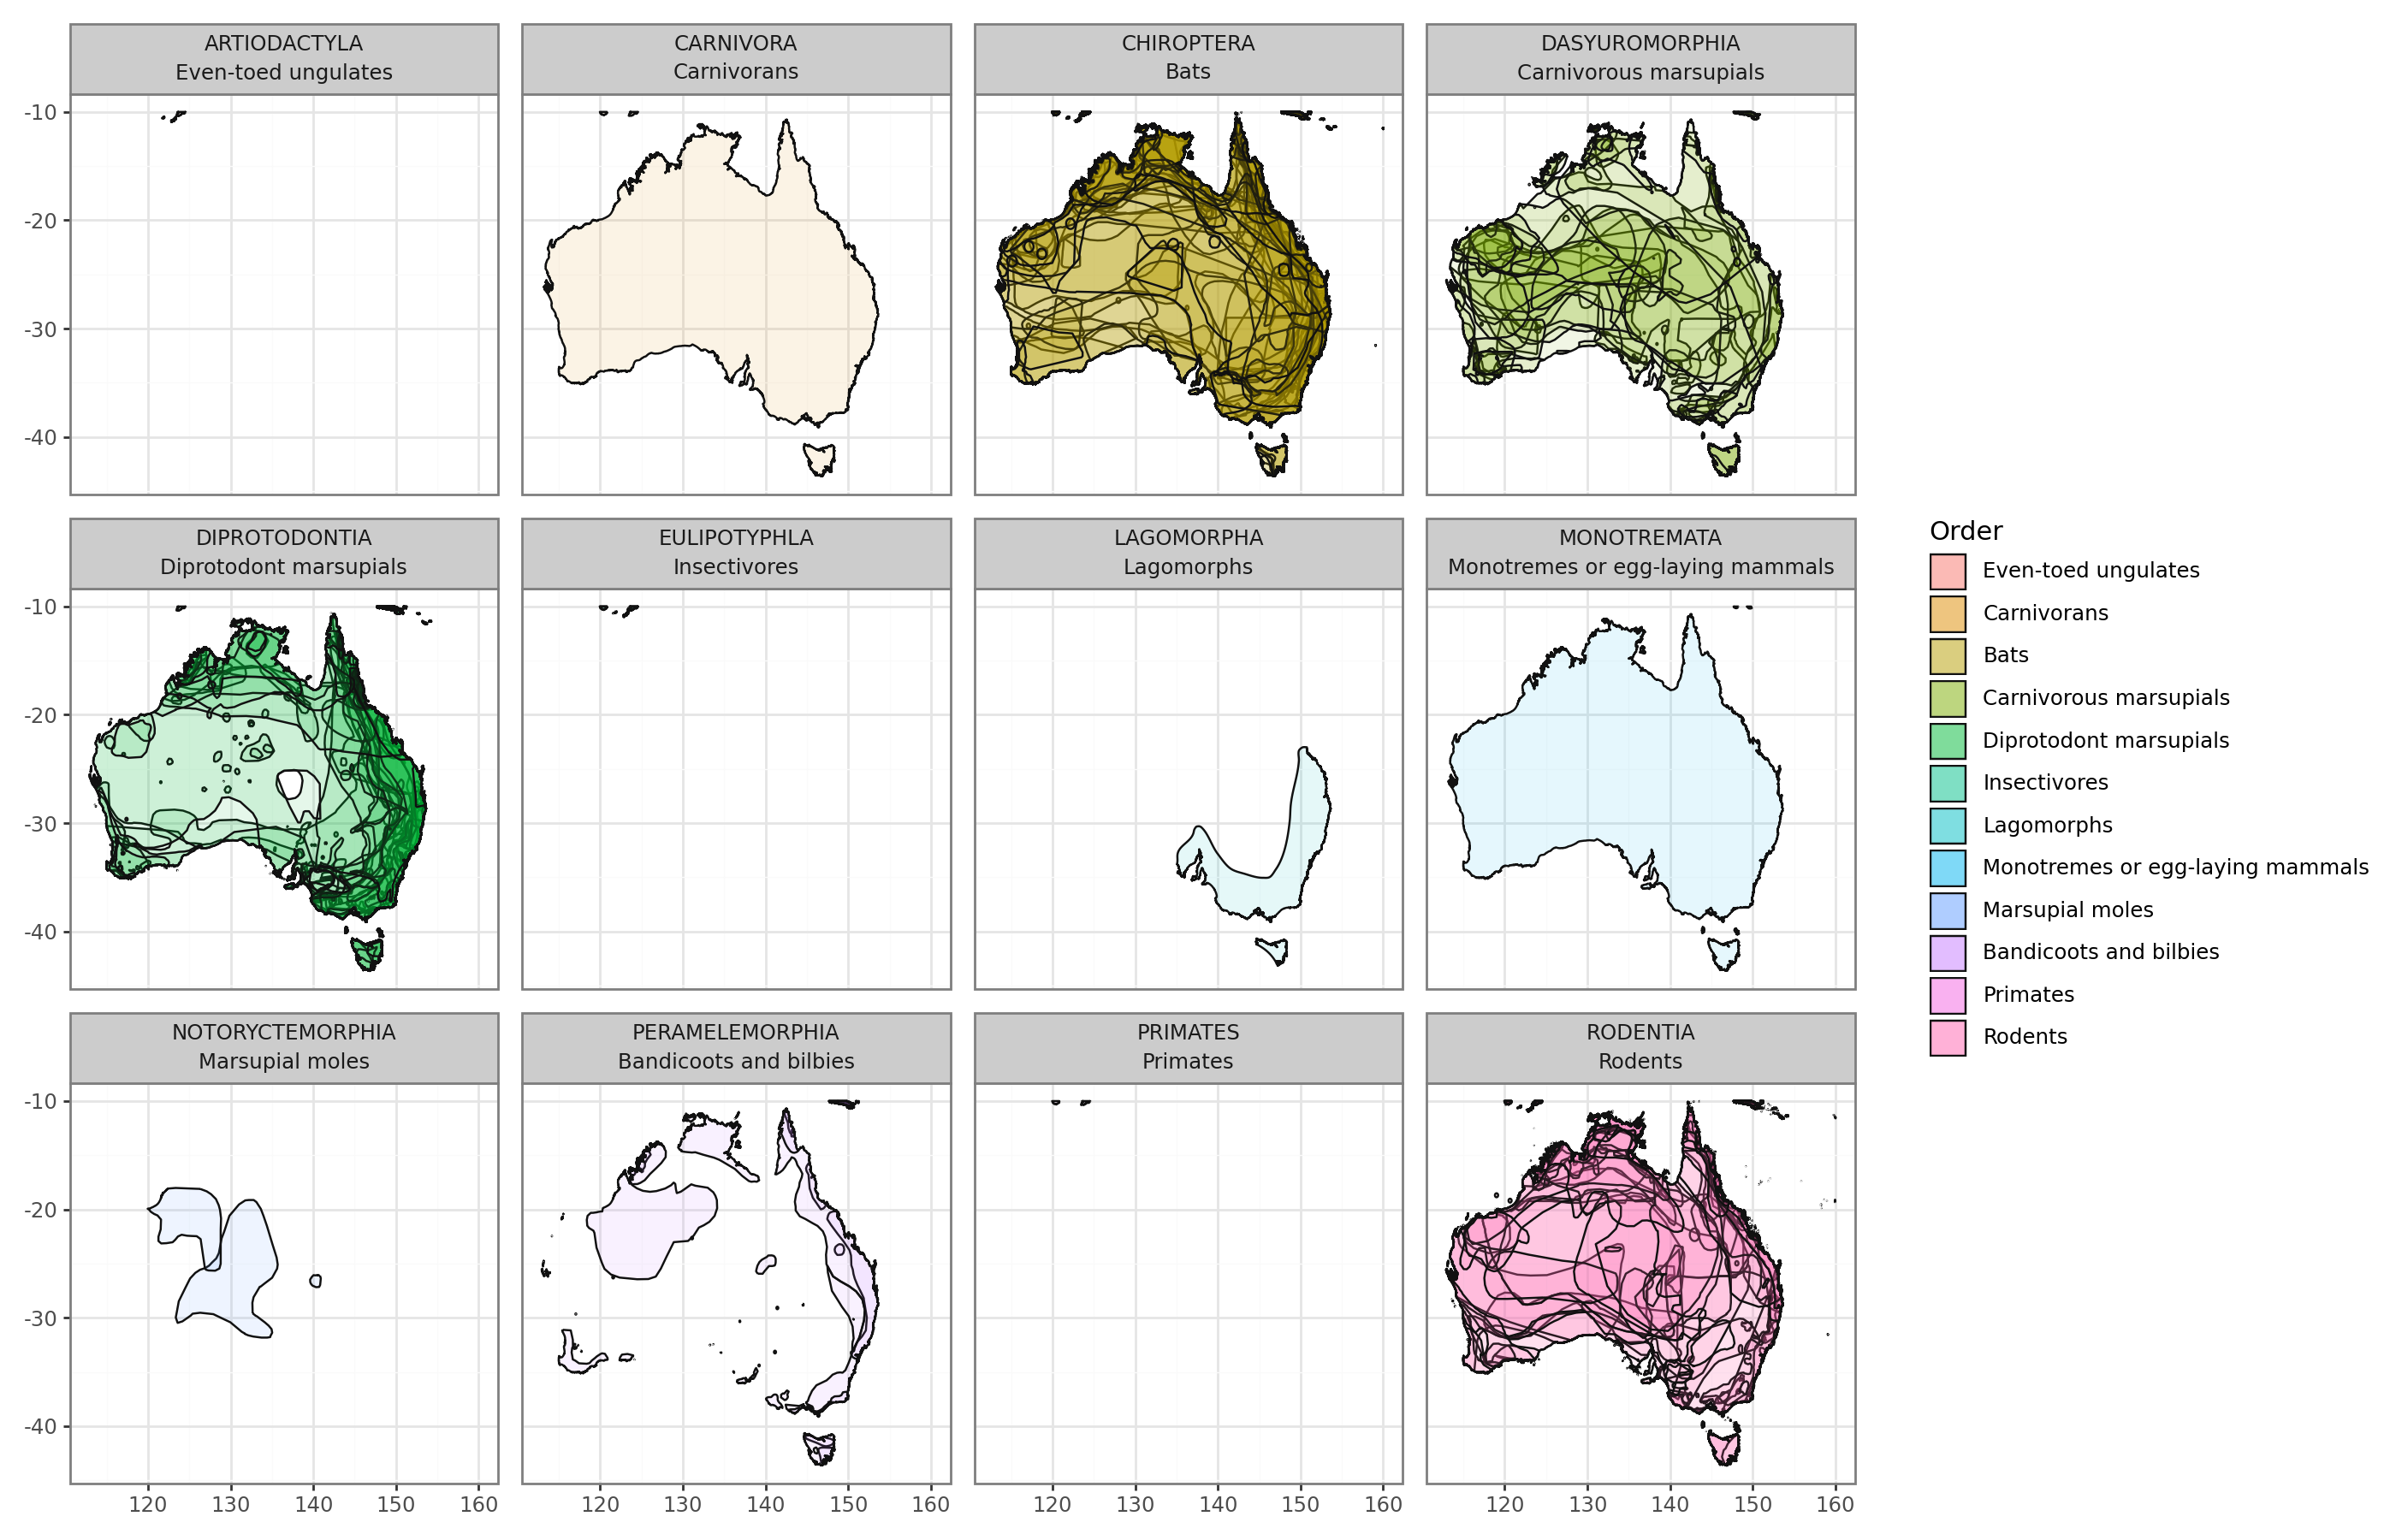

In [66]:
plot = (
    # set data source
    p9.ggplot(data=gdf_oz)
    # draw map, filling specie ranges of the same order to same color (mostly transparent)
    + p9.geom_map(
        mapping=p9.aes(fill="order_"),
        alpha=0.1,
    )
    # draw a seperate mini-map for each order, in a grid 4 maps across. Include
    # common name in each mini-map header
    + p9.facet_wrap("order_", ncol=4, labeller=order_namer)
    # go for black&white theme (cleanest)
    + p9.theme_bw()
    # set size of graphic
    + p9.theme(figure_size=(14, 9))
    # set title of legend
    + p9.labs(fill="Order")
    # set labels in legend to have common names only
    + p9.scale_fill_discrete(labels=list(common_names.values()))
    # set the fill legend color patches to be 50% opaque (not 10%)
    + p9.guides(
        fill=p9.guide_legend(
            override_aes={"alpha": 0.5}  # Legend squares are more opaque for clarity
        )
    )
)
plot

------------------

## Focus on smaller polygons

Show dataframe attributes

In [67]:
gdf_oz.head(1)

,id_no,sci_name,presence,origin,seasonal,compiler,yrcompiled,citation,subspecies,subpop,...,order_,family,genus,category,marine,terrestria,freshwater,SHAPE_Leng,SHAPE_Area,geometry
6675,19330,Rattus exulans,1,3,1,IUCN,2014,IUCN (International Union for Conservation of ...,NaN,NaN,...,RODENTIA,MURIDAE,Rattus,LC,false,true,false,302.019583,91.433451,"MULTIPOLYGON (((149.8567 -10.00486, 149.8583 -..."


Select mammal ranges with an area less than 1 square degree, and compute the center of each range (approximately). We have about 600 such ranges

In [68]:
gdf_oz_small = gdf_oz[gdf_oz["SHAPE_Area"] < 1.0].copy()

gdf_oz_small["geometry"] = gdf_oz_small.centroid

len(gdf_oz_small)

C:\Users\donrc\AppData\Local\Temp\ipykernel_35776\24563832.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



599

Show the counts of Orders, Genus, Family and Species found in small ranges  (not saying that they might not be found in larger ranges as well)

In [69]:
print(f"""
Order count   =  {len(gdf_oz_small["order_"].unique()):4}, 
Genus count   =  {len(gdf_oz_small["genus"].unique()):4},  
Family count  =  {len(gdf_oz_small["family"].unique()):4}, 
Species count =  {len(gdf_oz_small["sci_name"].unique()):4}""")


Order count   =     9, 
Genus count   =    95,  
Family count  =    28, 
Species count =   200


-------------------------

### Matplotlib

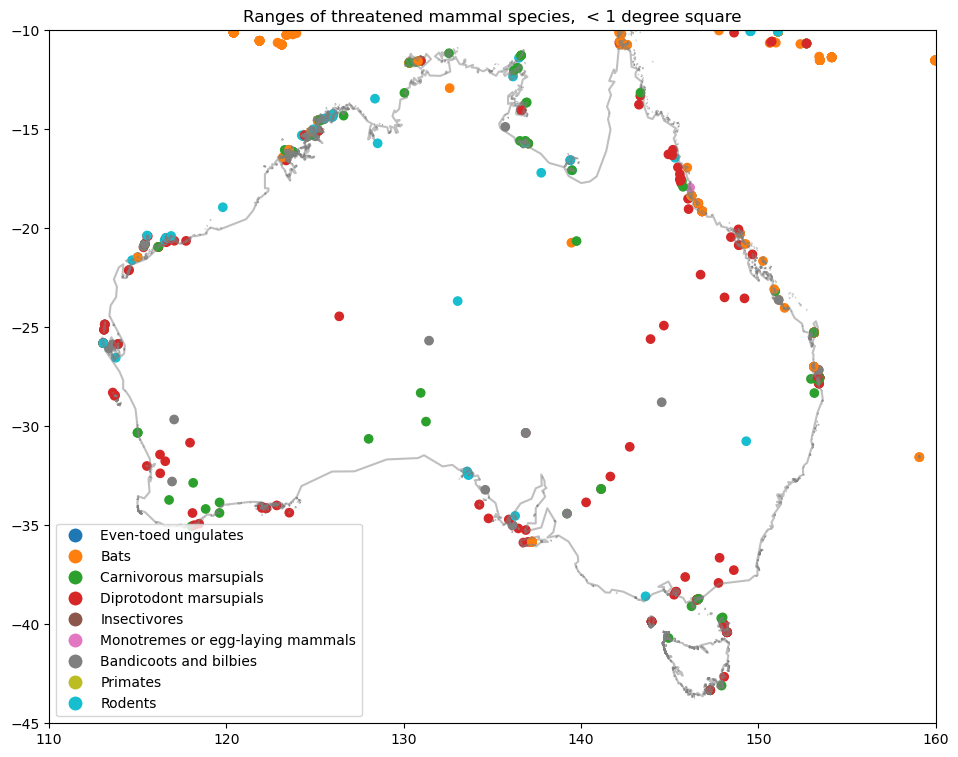

In [70]:
f, ax = plt.subplots(figsize=(14, 9))

gdf_oz_small.plot("order_", ax=ax, legend=True)
oz_coast.boundary.plot(ax=ax, alpha=0.5, color="gray")
# set the limit to our bounding box for map
ax.set_xlim(left=minx, right=maxx)
ax.set_ylim(bottom=miny, top=maxy)
ax.set_title("Ranges of threatened mammal species,  < 1 degree square")

# replace Order names in legend labels with common names
for text in ax.get_legend().get_texts():
    s = text.get_text()
    common = common_names[s]
    text.set_text(common)

# end for

---------------------

### Plotnine

First reproduce plot above

In [71]:
common_names_small = [common_names[o] for o in sorted(gdf_oz_small["order_"].unique())]
common_names_small

['Even-toed ungulates',
 'Bats',
 'Carnivorous marsupials',
 'Diprotodont marsupials',
 'Insectivores',
 'Monotremes or egg-laying mammals',
 'Bandicoots and bilbies',
 'Primates',
 'Rodents']

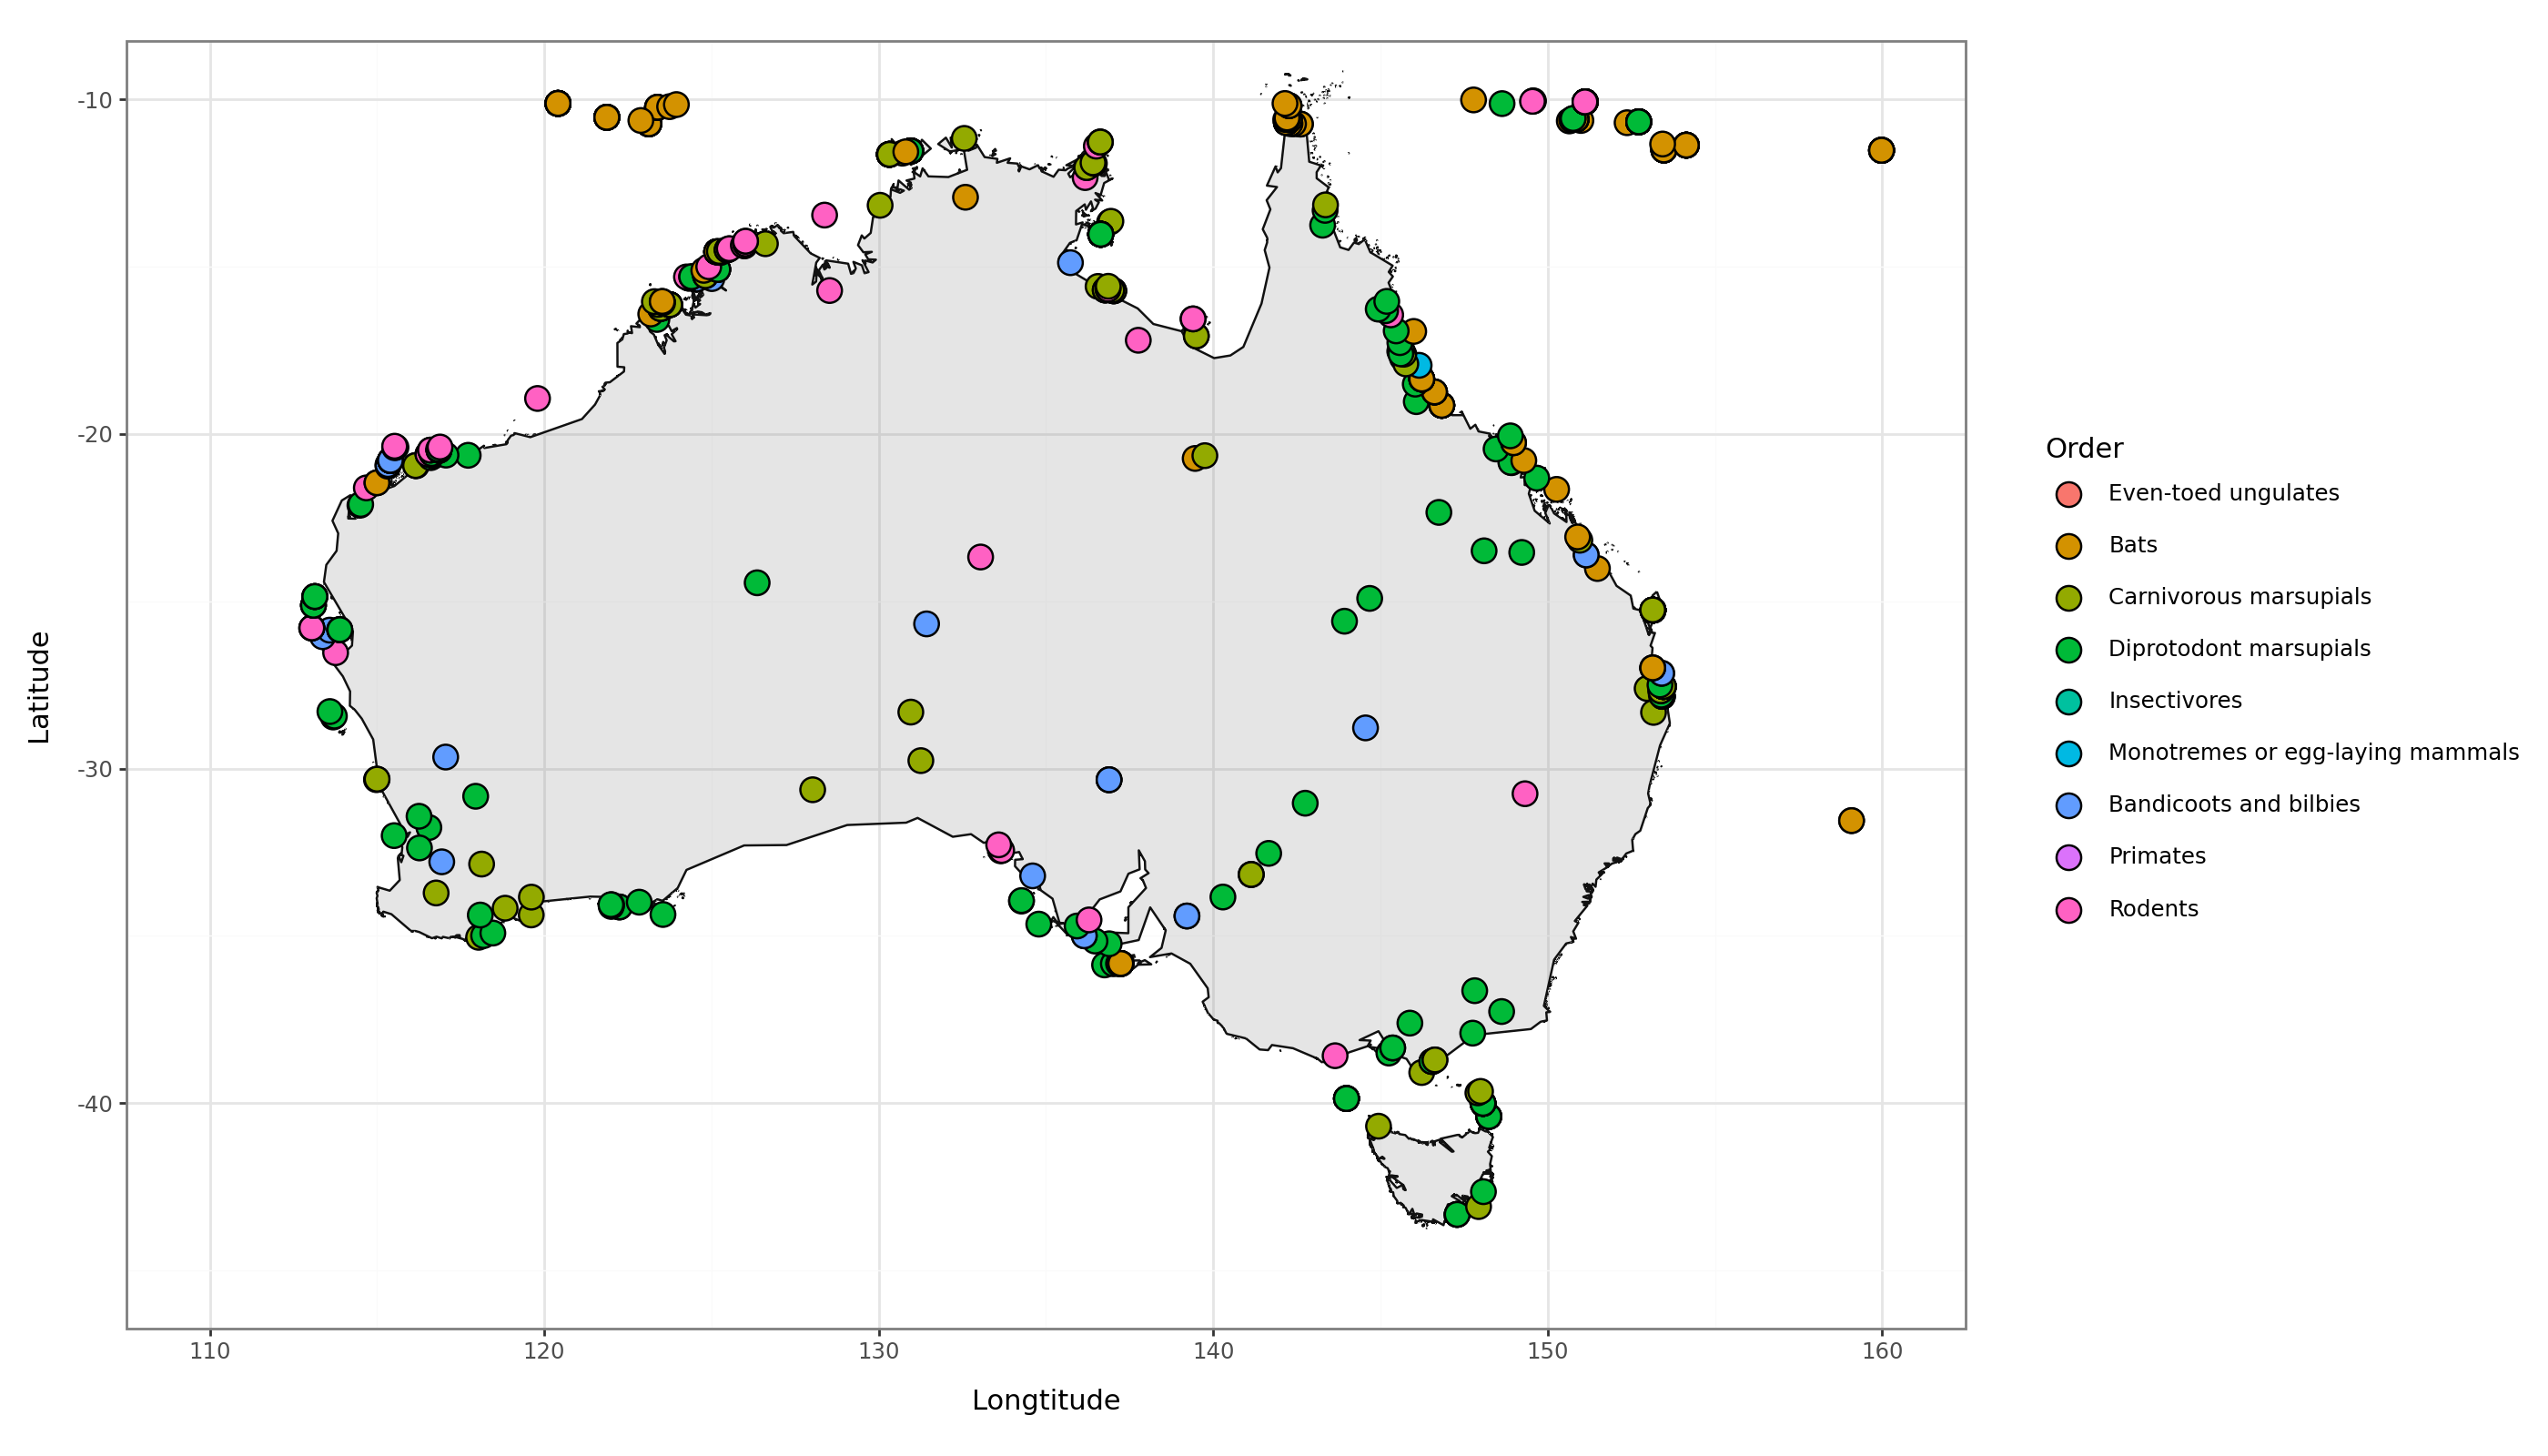

In [72]:
plot = (
    # define default dataset
    p9.ggplot(data=gdf_oz_small)
    # draw the coastline, light gray fill
    + p9.geom_map(
        data=oz_coast,
        mapping=p9.aes(
            geometry="geometry",
        ),
        fill="gray",
        alpha=0.2,
    )
    # draw a point marker at range centroids, color-coded for Order, fixed size
    + p9.geom_point(
        mapping=p9.aes(
            x="geometry.x",
            y="geometry.y",
            fill="order_",
        ),
        size=5,
    )
    # go for black&white theme (cleanest)
    + p9.theme_bw()
    # set size of graphic
    + p9.theme(figure_size=(14, 8))
    # set title of legend and axis
    + p9.labs(
        fill="Order",
        x="Longtitude",
        y="Latitude",
    )
    # set common names in legend labels
    + p9.scale_fill_discrete(
        labels=common_names_small,
    )
    # make x and y scale the same
    + p9.coord_equal(xlim=(minx, maxx), ylim=(miny, maxy))
)
plot

Now scale marker size _and_ set color based upon Order

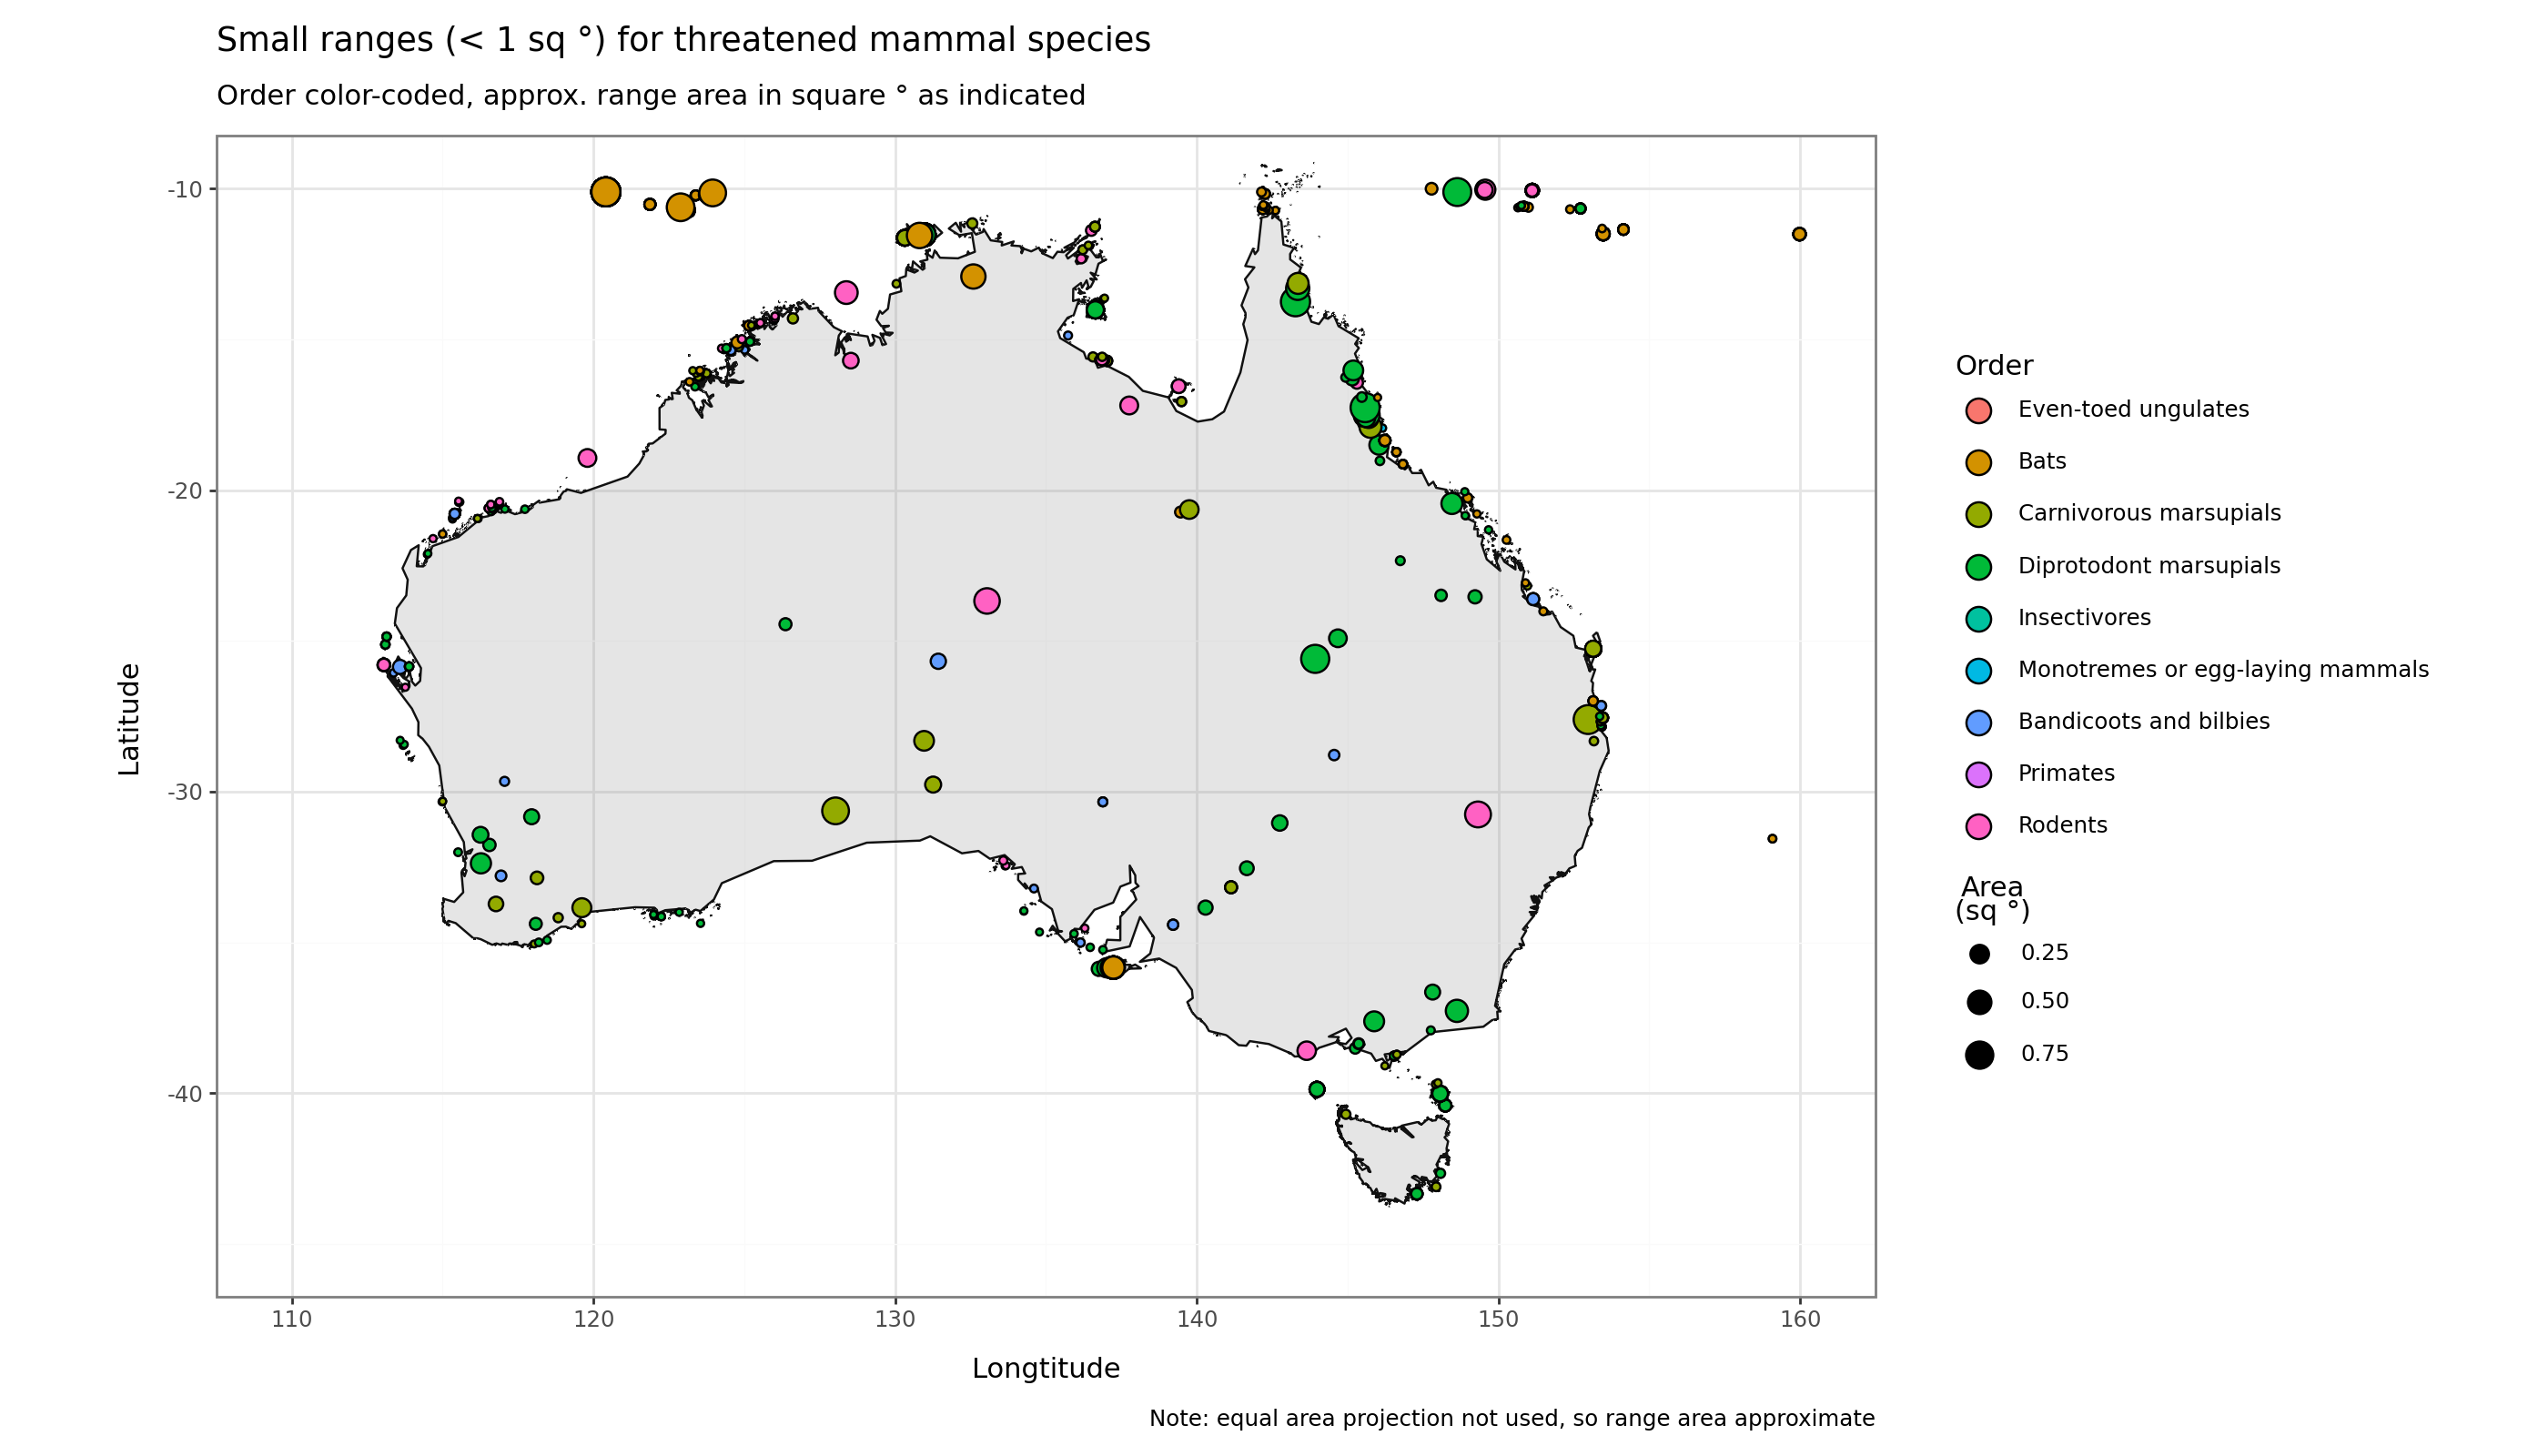

In [73]:
plot = (
    # define default dataset
    p9.ggplot(data=gdf_oz_small)
    # draw the coastline, light gray fill
    + p9.geom_map(
        data=oz_coast,
        mapping=p9.aes(
            geometry="geometry",
        ),
        fill="gray",
        alpha=0.2,
    )
    # draw a point marker at range centroids, color-coded for Order, variable size
    + p9.geom_point(
        mapping=p9.aes(
            x="geometry.x",
            y="geometry.y",
            fill="order_",
            size="SHAPE_Area",
        ),
    )
    # go for black&white theme (cleanest)
    + p9.theme_bw()
    # set size of graphic
    + p9.theme(figure_size=(14, 8))
    # set textt of legends, etc
    + p9.labs(
        fill="Order",
        size="Area\n(sq °)",
        title="Small ranges (< 1 sq °) for threatened mammal species",
        subtitle="Order color-coded, approx. range area in square ° as indicated",
        caption="Note: equal area projection not used, so range area approximate",
        x="Longtitude",
        y="Latitude",
    )
    # set common names in legend labels
    + p9.scale_fill_discrete(
        labels=common_names_small,
    )
    # make x and y scale the same
    + p9.coord_equal(xlim=(minx, maxx), ylim=(miny, maxy))
    # change size of legend color patches for clarity
    + p9.guides(
        fill=p9.guide_legend(
            override_aes={"size": 5}  # Legend squares are bigger for clarity
        )
    )
)
plot

------------------------

### Small range outlines

Finally we draw just the small ranges.  It brings out the idea that small ranges are prevelant in  coastal or island setting

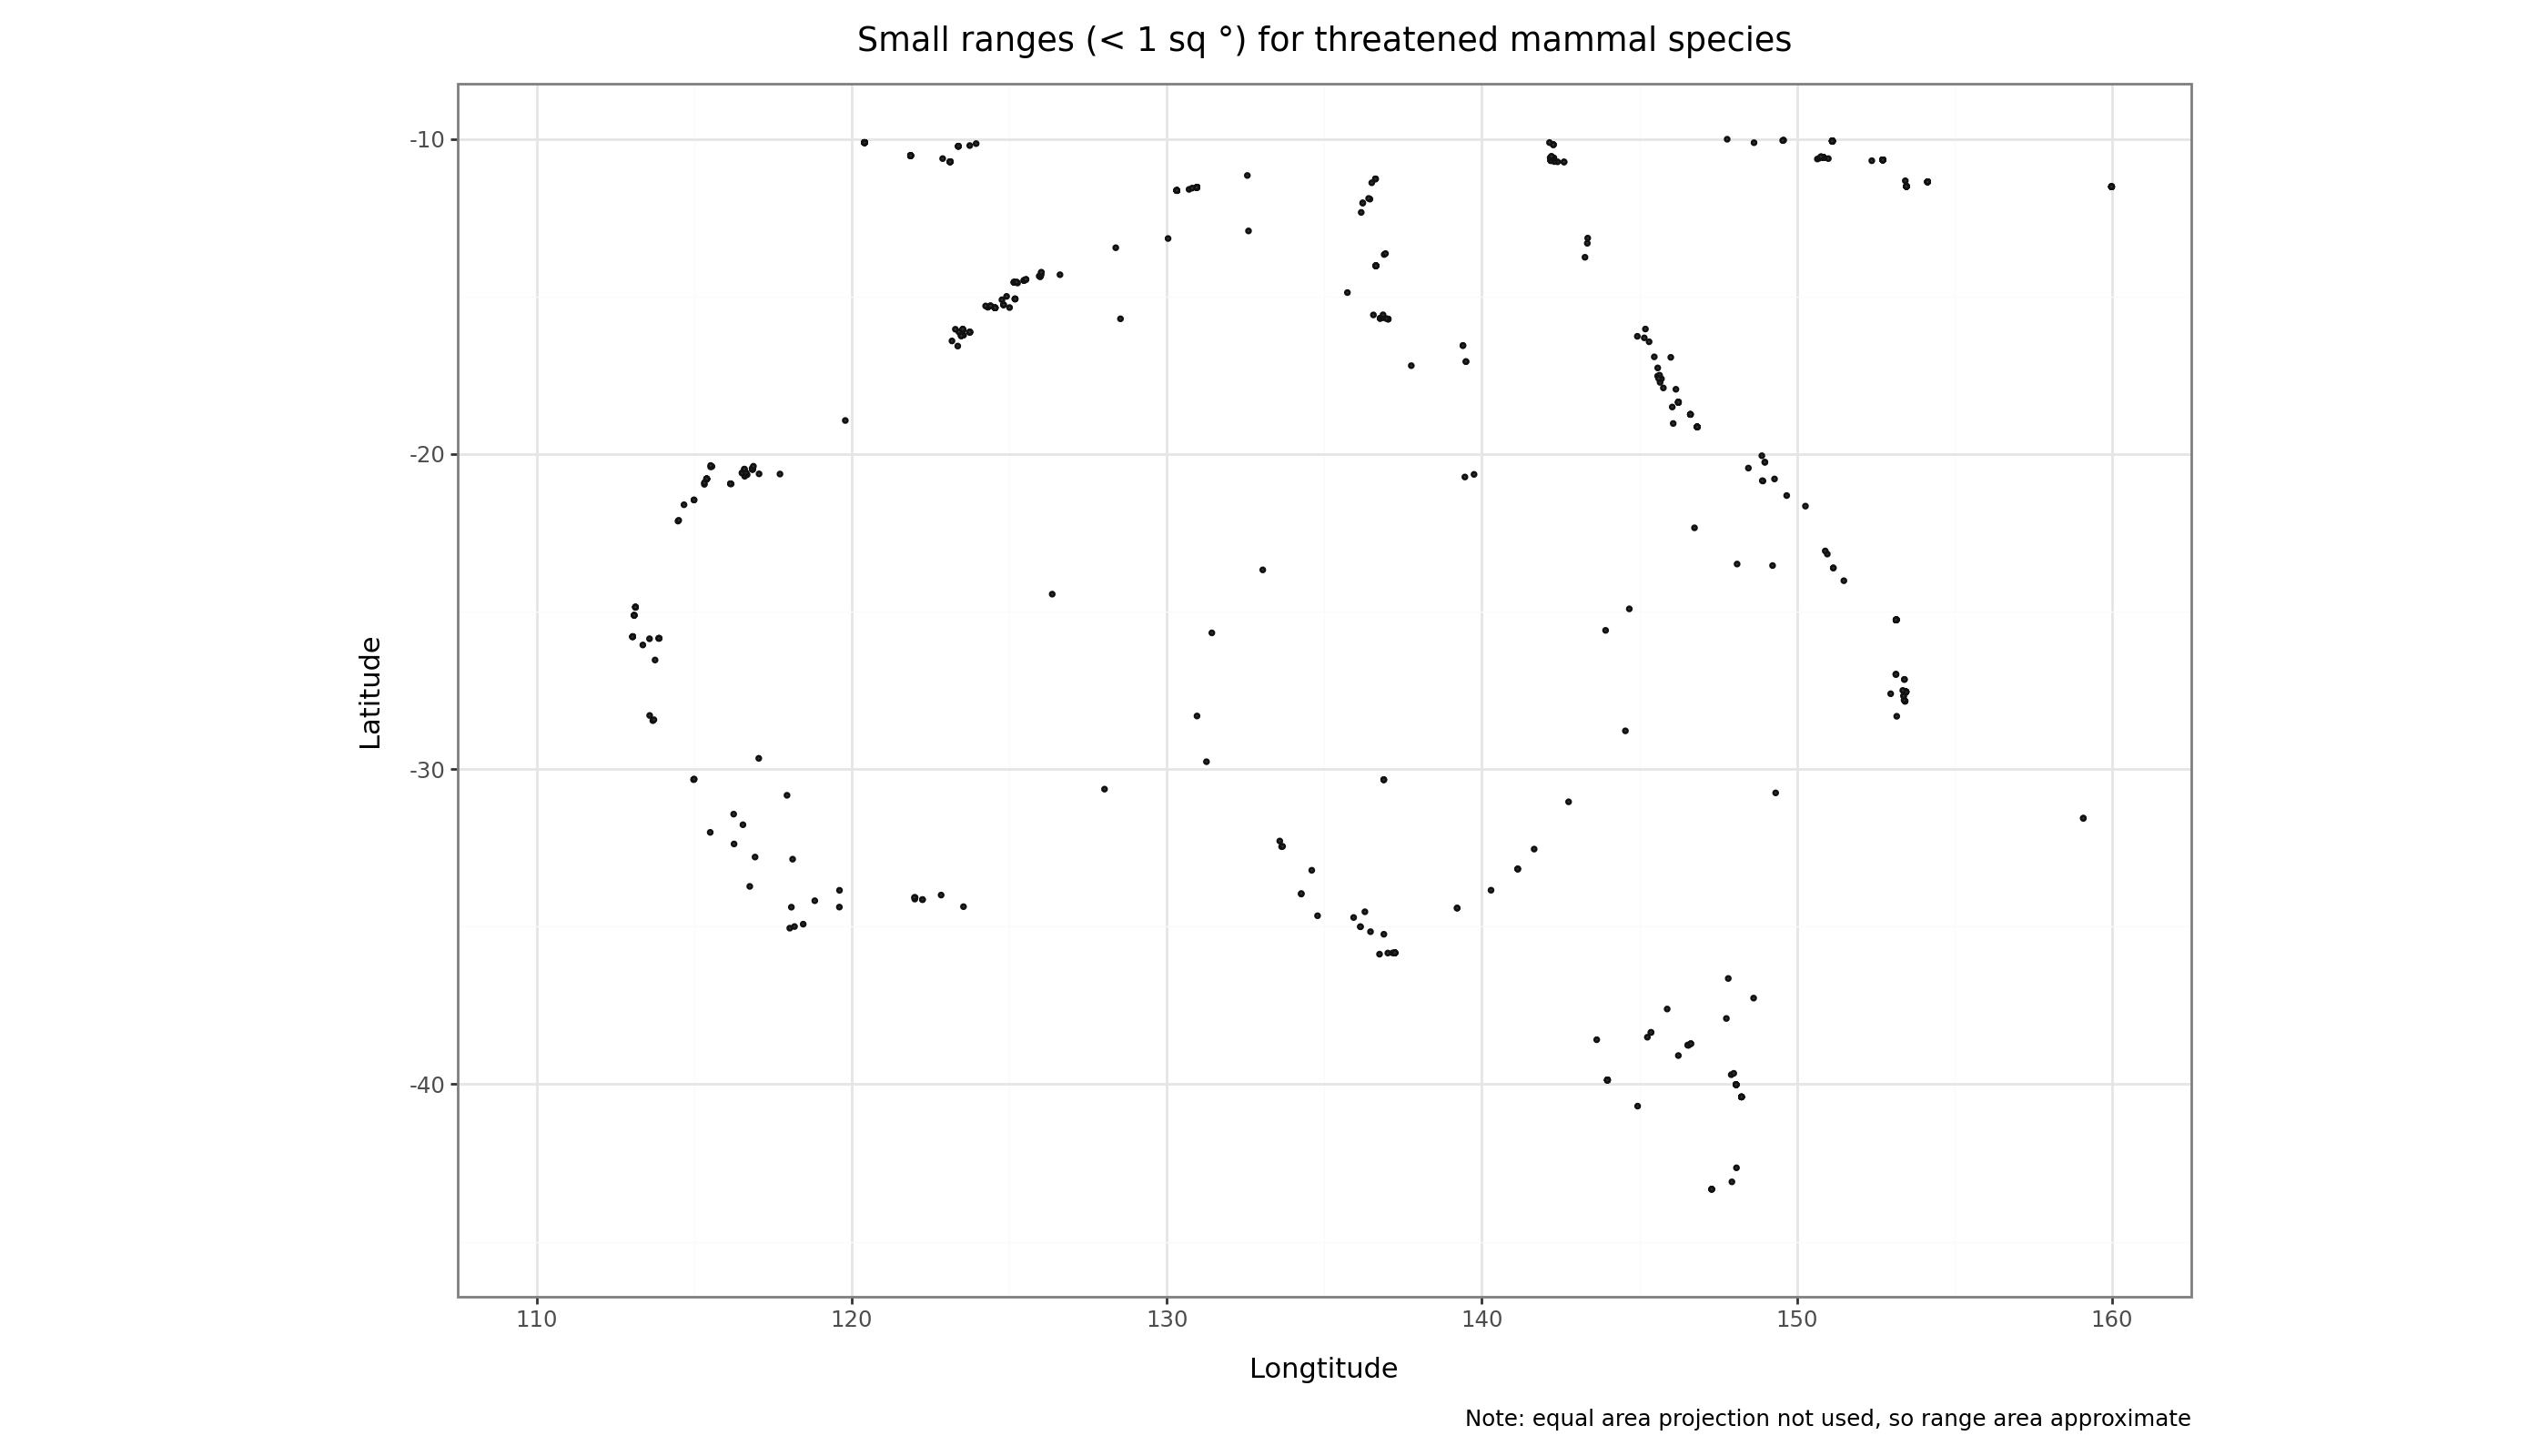

In [74]:
plot = (
    # define default dataset
    p9.ggplot(data=gdf_oz_small)
    # draw the small ranges
    + p9.geom_map(
        mapping=p9.aes(
            geometry="geometry",
        )
    )
    # go for black&white theme (cleanest)
    + p9.theme_bw()
    # set size of graphic
    + p9.theme(figure_size=(14, 8))
    # set text of titles, etc
    + p9.labs(
        title="Small ranges (< 1 sq °) for threatened mammal species",
        caption="Note: equal area projection not used, so range area approximate",
        x="Longtitude",
        y="Latitude",
    )
    # make x and y scale the same
    + p9.coord_equal(xlim=(minx, maxx), ylim=(miny, maxy))
)
plot

----------------------------------------

## Conclusions

in my view, __plotnine__ (especially using __facet_wrap__) produces the most elegant maps

## Reproducability

In [75]:
%watermark

Last updated: 2026-04-11T08:52:17.660487+10:00

Python implementation: CPython
Python version       : 3.11.15
IPython version      : 9.10.1

Compiler    : MSC v.1944 64 bit (AMD64)
OS          : Windows
Release     : 10
Machine     : AMD64
Processor   : Intel64 Family 6 Model 170 Stepping 4, GenuineIntel
CPU cores   : 22
Architecture: 64bit



In [76]:
%watermark -h -iv -co

conda environment: 30DayMapChallenge2025

Hostname: INSPIRON16

geodatasets: 2026.1.0
geopandas  : 1.1.3
matplotlib : 3.10.8
numpy      : 1.26.4
plotnine   : 0.15.3
shapely    : 2.1.2



In [77]:
import contextlib

import ipynbname

with contextlib.suppress(FileNotFoundError):
    print(f"Notebook file name: {ipynbname.name()}")
# end with

Notebook file name: eco_boundaries
